# Overlap quota: does it help to separate colliding classes? (axis-100-3000)

The overlap quota adds synthetic tokens for classes that share a bin with another class in a training pixel (spectral collisions): a 'seed' of where each colliding class is. If it works, the model should discriminate the annotated class of a colliding pair from its partner better than the baseline and than the matched variant without the quota.

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

* **Collision pairs** are the class pairs co-annotated at the same bin of the same training pixel (regenerated
  synthetic artifact). The analysis is limited to pairs with at least `minimum_pair_pixels` evaluable pixels.
* **Matched controls.** P3 vs P2 and P5 vs P4 (joint and staged) differ only in the overlap quota.
* **Secondary analysis.** Pixels grouped by their number of annotated classes (spatial co-occurrence), with the
  label-ranking average precision (LRAP) per group.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

* For a pair $(a, b)$ and pixels where exactly one of them is annotated: *discrimination* = fraction of pixels in
  which the annotated class scores higher; *margin* = mean logit difference (annotated - partner); *false-positive
  rate when the partner is present* = rate at which the absent class is predicted ($p \ge 0.5$) where its partner
  is annotated; *false-positive lift* = that rate minus the rate where both are absent (lower is better).

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "overlap_classes"
AXIS = "axis-100-3000"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

pairs = table('pairs')
pair_summary = table('pair_summary')
baseline_summary = table('baseline_summary')
PAIRS = settings['targeted']['overlap']['pairs']
TREATED = list(PAIRS)
PAIR_LABELS = {treated: f"{VARIANT_LABELS[treated]} - {VARIANT_LABELS[control]}" for treated, control in PAIRS.items()}
print('Collision pairs:', metadata['collision_pairs'], '| overlap classes:', metadata['overlap_classes'],
      '| minimum pair pixels:', metadata['minimum_pair_pixels'])

Analysis: overlap_classes | axis: axis-100-3000 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}
Collision pairs: 4 | overlap classes: 8 | minimum pair pixels: 5


## Producing the tables this notebook reads

### Methodology

#### Implementation

`overlap_classes` reads the collision pairs of the regenerated synthetic artifact, the stored logits and the
annotations of every model's evaluation populations, and computes the pairwise discrimination, the class-set
metrics and the co-occurrence LRAP.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis overlap_classes > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Absolute metrics of the targeted class sets against the real-only baseline

### Methodology

#### Theoretical

The improvements and matched controls below are differences; this section shows the level of every
targeted class-set metric for the real-only baseline and every variant at every stage.

#### Implementation

`set_metrics` holds one value per model, class set, metric and evaluation population.

#### Figure descriptions

        Figure: one panel per metric; x = real-only baseline and the stages (every variant's repetitions pooled per
        stage; 50 models per stage against 5 baseline models), violin and points = models. Tables (one per metric): rows
        = baseline and variants, columns = stages; the baseline row repeats the baseline value in every stage column so
        that each cell is compared with it.
        Last figure: the unfrozen-head stage only, split by variant (x = real-only baseline and every variant, five
        repetitions each), because pooling the variants of a stage mixes variants with very different effects.

Colours: in the figures the baseline is grey (its mean is the dashed line) and every other group is green when its
mean is better than the baseline mean and red when it is worse. In the tables every cell is mean +/- SD over the
repetitions; green / red cells are better / worse than the baseline cell of the same column (stronger colour = larger
difference within the column), the black frame marks the three best rows of the column and the grey bold row is the
real-only baseline.

In [3]:
LOWER_IS_BETTER = {'masserstein', 'spectral_angle', 'mse', 'hamming_loss', 'expected_calibration_error', 'brier_score',
                   'within', 'contribution', 'absolute_mass_imbalance', 'bic'}
METRIC_ORDER = ['average_precision', 'micro_average_precision', 'roc_auc', 'micro_roc_auc', 'ap_above_prevalence',
                'precision', 'recall', 'f1', 'micro_precision', 'micro_recall', 'micro_f1', 'micro_prevalence',
                'hamming_loss']
ABS_ORDER = [BASELINE, *VARIANTS]
LABELS_ABS = {**VARIANT_LABELS, **{name: VARIANT_LABELS.get(name, name) for name in ABS_ORDER}}


def better(metric):
    """Direction of a metric: 'lower' or 'higher' is better."""
    return 'lower' if metric in LOWER_IS_BETTER else 'higher'

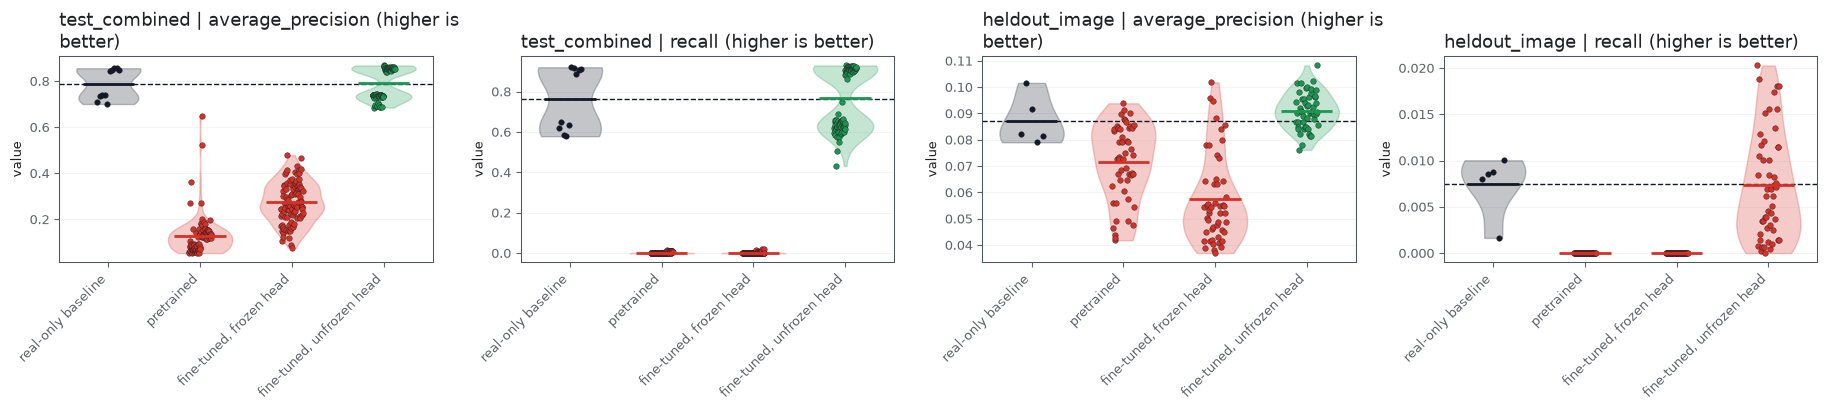

test_combined | average_precision


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.788 +/- 0.068,0.788 +/- 0.068,0.788 +/- 0.068
P0_single,0.123 +/- 0.068,0.265 +/- 0.070,0.802 +/- 0.067
P1_permutation,0.263 +/- 0.193,0.184 +/- 0.057,0.790 +/- 0.070
P2_joint_base,0.102 +/- 0.034,0.298 +/- 0.072,0.785 +/- 0.070
P2_staged_base,0.112 +/- 0.047,0.274 +/- 0.061,0.789 +/- 0.067
P3_joint_overlap,0.117 +/- 0.041,0.343 +/- 0.073,0.791 +/- 0.069
P3_staged_overlap,0.102 +/- 0.037,0.294 +/- 0.075,0.792 +/- 0.067
P4_joint_rare,0.116 +/- 0.037,0.329 +/- 0.097,0.780 +/- 0.078
P4_staged_rare,0.107 +/- 0.039,0.229 +/- 0.069,0.797 +/- 0.062


test_combined | recall


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.761 +/- 0.157,0.761 +/- 0.157,0.761 +/- 0.157
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.760 +/- 0.143
P1_permutation,0.000 +/- 0.000,0.002 +/- 0.005,0.744 +/- 0.179
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.754 +/- 0.174
P2_staged_base,0.002 +/- 0.004,0.002 +/- 0.003,0.775 +/- 0.151
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.752 +/- 0.166
P3_staged_overlap,0.004 +/- 0.006,0.002 +/- 0.002,0.775 +/- 0.153
P4_joint_rare,0.001 +/- 0.003,0.001 +/- 0.002,0.776 +/- 0.148
P4_staged_rare,0.005 +/- 0.005,0.005 +/- 0.008,0.787 +/- 0.145


heldout_image | average_precision


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.087 +/- 0.009,0.087 +/- 0.009,0.087 +/- 0.009
P0_single,0.066 +/- 0.017,0.056 +/- 0.016,0.092 +/- 0.006
P1_permutation,0.047 +/- 0.006,0.051 +/- 0.004,0.085 +/- 0.008
P2_joint_base,0.078 +/- 0.008,0.064 +/- 0.022,0.094 +/- 0.005
P2_staged_base,0.073 +/- 0.007,0.057 +/- 0.026,0.087 +/- 0.006
P3_joint_overlap,0.083 +/- 0.009,0.060 +/- 0.022,0.091 +/- 0.006
P3_staged_overlap,0.080 +/- 0.013,0.060 +/- 0.020,0.090 +/- 0.007
P4_joint_rare,0.076 +/- 0.009,0.056 +/- 0.016,0.089 +/- 0.008
P4_staged_rare,0.069 +/- 0.016,0.062 +/- 0.019,0.095 +/- 0.005


heldout_image | recall


stage,pretrained,frozen_head,unfrozen_head
variant,,,
baseline,0.007 +/- 0.003,0.007 +/- 0.003,0.007 +/- 0.003
P0_single,0.000 +/- 0.000,0.000 +/- 0.000,0.012 +/- 0.008
P1_permutation,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.006
P2_joint_base,0.000 +/- 0.000,0.000 +/- 0.000,0.006 +/- 0.005
P2_staged_base,0.000 +/- 0.000,0.000 +/- 0.000,0.005 +/- 0.006
P3_joint_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.004 +/- 0.002
P3_staged_overlap,0.000 +/- 0.000,0.000 +/- 0.000,0.007 +/- 0.006
P4_joint_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.004 +/- 0.002
P4_staged_rare,0.000 +/- 0.000,0.000 +/- 0.000,0.009 +/- 0.005


In [4]:
frame_abs = table('set_metrics')

SELECTORS_ABS = [["test_combined | average_precision", {"evaluation": "test_combined", "metric": "average_precision"}, "higher"], ["test_combined | recall", {"evaluation": "test_combined", "metric": "recall"}, "higher"], ["heldout_image | average_precision", {"evaluation": "heldout_image", "metric": "average_precision"}, "higher"], ["heldout_image | recall", {"evaluation": "heldout_image", "metric": "recall"}, "higher"]]
STAGE_ORDER = ['real_only', *STAGES]
figures.metric_panels(frame_abs, panels=[(label, selector, direction) for label, selector, direction in SELECTORS_ABS], group='stage',
                      order=STAGE_ORDER, labels=STAGE_LABELS, baseline='real_only', columns=4, theme=theme);
plt.show()
for label, selector, direction in SELECTORS_ABS:
    rows = frame_abs
    for column, value in selector.items():
        rows = rows[rows[column] == value]
    base = rows[rows.stage == 'real_only']
    grid = pd.concat([rows[rows.stage != 'real_only'], *[base.assign(stage=stage) for stage in STAGES]])
    print(label)
    display(figures.comparison_table(grid, index='variant', columns='stage', baseline=BASELINE, order=ABS_ORDER,
                                     column_order=STAGES, direction={stage: direction for stage in STAGES}))

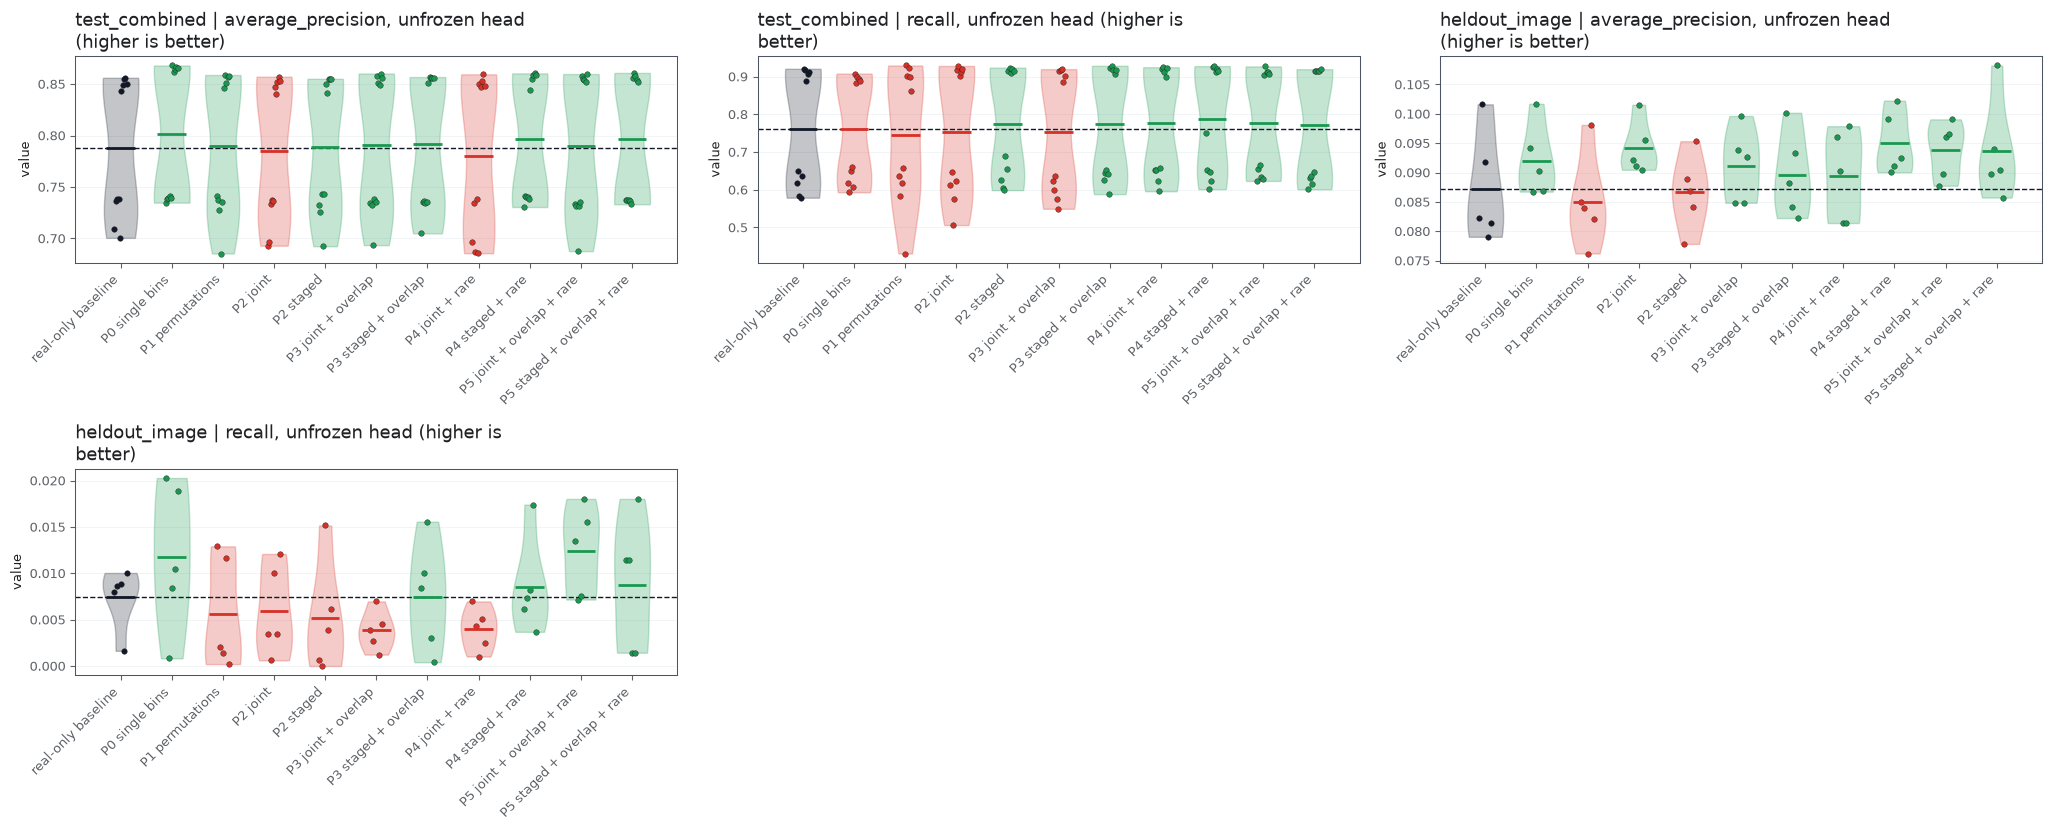

In [5]:
## Unfrozen-head stage per variant (the pooled figure above mixes variants with different effects)
unfrozen = frame_abs[frame_abs.stage.isin(['real_only', 'unfrozen_head'])] if 'frame_abs' in globals() else metrics_abs[metrics_abs.stage.isin(['real_only', 'unfrozen_head'])]
figures.metric_panels(unfrozen, panels=[(f'{label}, unfrozen head', selector, direction) for label, selector, direction in SELECTORS_ABS],
                      group='variant', order=ABS_ORDER, labels=LABELS_ABS, baseline=BASELINE, columns=3, theme=theme);

### Remarks

- test_combined | average_precision (by stage, variants pooled): baseline 0.7876; others 0.1264-0.7911; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7911), worst pretrained (0.1264).
- test_combined | average_precision (unfrozen head, per variant): baseline 0.7876; others 0.78-0.8019; 8 of 10 better than the baseline; best P0 single bins (0.8019), worst P4 joint + rare (0.78).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8019 vs baseline 0.7876).
- test_combined | recall (by stage, variants pooled): baseline 0.7614; others 0.001505-0.7672; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7672), worst fine-tuned, frozen head (0.001505).
- test_combined | recall (unfrozen head, per variant): baseline 0.7614; others 0.7439-0.7875; 6 of 10 better than the baseline; best P4 staged + rare (0.7875), worst P1 permutations (0.7439).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.7875 vs baseline 0.7614).
- heldout_image | average_precision (by stage, variants pooled): baseline 0.08724; others 0.05764-0.09105; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.09105), worst fine-tuned, frozen head (0.05764).
- heldout_image | average_precision (unfrozen head, per variant): baseline 0.08724; others 0.08506-0.09499; 8 of 10 better than the baseline; best P4 staged + rare (0.09499), worst P1 permutations (0.08506).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.09499 vs baseline 0.08724).
- heldout_image | recall (by stage, variants pooled): baseline 0.007415; others 0-0.007354; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.007354), worst fine-tuned, frozen head (0).
- heldout_image | recall (unfrozen head, per variant): baseline 0.007415; others 0.003851-0.01237; 5 of 10 better than the baseline; best P5 joint + overlap + rare (0.01237), worst P3 joint + overlap (0.003851).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.01237 vs baseline 0.007415).

### Notes

## Collision pairs and their support

### Methodology

#### Theoretical

The pairs are the classes the overlap quota targets. Their support on the evaluation pixels bounds the power
of the analysis.

#### Implementation

`pairs` (training co-annotations and pixels) and `pair_summary` (number of pairs with enough pixels per evaluation).

#### Figure descriptions

No figure.

In [6]:
display(pairs)
display(pair_summary.groupby('evaluation').pairs.agg(['min', 'max']))

,class_a,class_b,co_annotations,pixels,class_a_name,class_b_name
0,21,337,1559,1559,C10H9Cl3O2|-H,C3H8O10P2|-H
1,365,418,3133,3133,C42H80NO10P|-H,C45H76NO8P|-H
2,411,435,21599,21599,C44H85NO11S|-H,C46H78NO10P|-H
3,447,469,25813,25813,C46H89NO11S|-H,C48H82NO10P|-H


,min,max
evaluation,,
heldout_image,0,0
test_combined,4,4


### Remarks

- 4 collision pairs, 1559-25813 training pixels each: C10H9Cl3O2|-H / C3H8O10P2|-H; C42H80NO10P|-H / C45H76NO8P|-H; C44H85NO11S|-H / C46H78NO10P|-H; C46H89NO11S|-H / C48H82NO10P|-H.
- Supported pairs on the held-out images: 0; the pair analysis is therefore limited to test + extension.

### Notes

## Pair discrimination against the baseline

### Methodology

#### Theoretical

Pixel-weighted mean over the supported pairs of discrimination, margin and false-positive lift, paired
against the baseline.

#### Implementation

`baseline_improvements` and `baseline_summary` (test + extension; the held-out images contain no supported pair).

#### Figure descriptions

Forest plot: rows = variants, panels = metric x stage.

discrimination                                         margin                                    false_positive_lift                                   
stage                frozen_head pretrained real_only unfrozen_head frozen_head pretrained real_only unfrozen_head         frozen_head pretrained real_only unfrozen_head
variant                                                                                                                                                                  
baseline                     NaN        NaN     0.857           NaN         NaN        NaN      5.15           NaN                 NaN        NaN     0.111           NaN
P0_single                  0.559      0.498       NaN         0.868      -0.002      0.008       NaN         3.754               0.000      0.000       NaN         0.098
P1_permutation             0.517      0.452       NaN         0.859       0.032     -0.008       NaN         5.076              -0.004      0.000       NaN         0.099
P2_joint_base              0.451      0.354       NaN         0.857      -0.076     -0.118       NaN         4.882               0.000      0.000       NaN         0.104
P2_staged_base             0.336      0.361       NaN         0.865      -0.164     -0.169       NaN         4.491              -0.000      0.000       NaN         0.107
P3_joint_overlap           0.663      0.676       NaN         0.855       0.256      0.235       NaN         4.528               0.000      0.000       NaN         0.096
P3_staged_overlap          0.584      0.491       NaN         0.858       0.095     -0.013       NaN         4.384              -0.000     -0.001       NaN         0.109
P4_joint_rare              0.327      0.225       NaN         0.852      -0.458     -0.410       NaN         5.377               0.000      0.000       NaN         0.121
P4_staged_rare             0.315      0.316       NaN         0.861      -0.353     -0.303       NaN         4.336              -0.000      0.000       NaN         0.128
P5_joint_all               0.417      0.488       NaN         0.859      -0.030      0.020       NaN         4.295               0.000      0.000       NaN         0.114
P5_staged_all              0.299      0.376       NaN         0.860      -0.201     -0.109       NaN         4.309              -0.001     -0.000       NaN         0.107

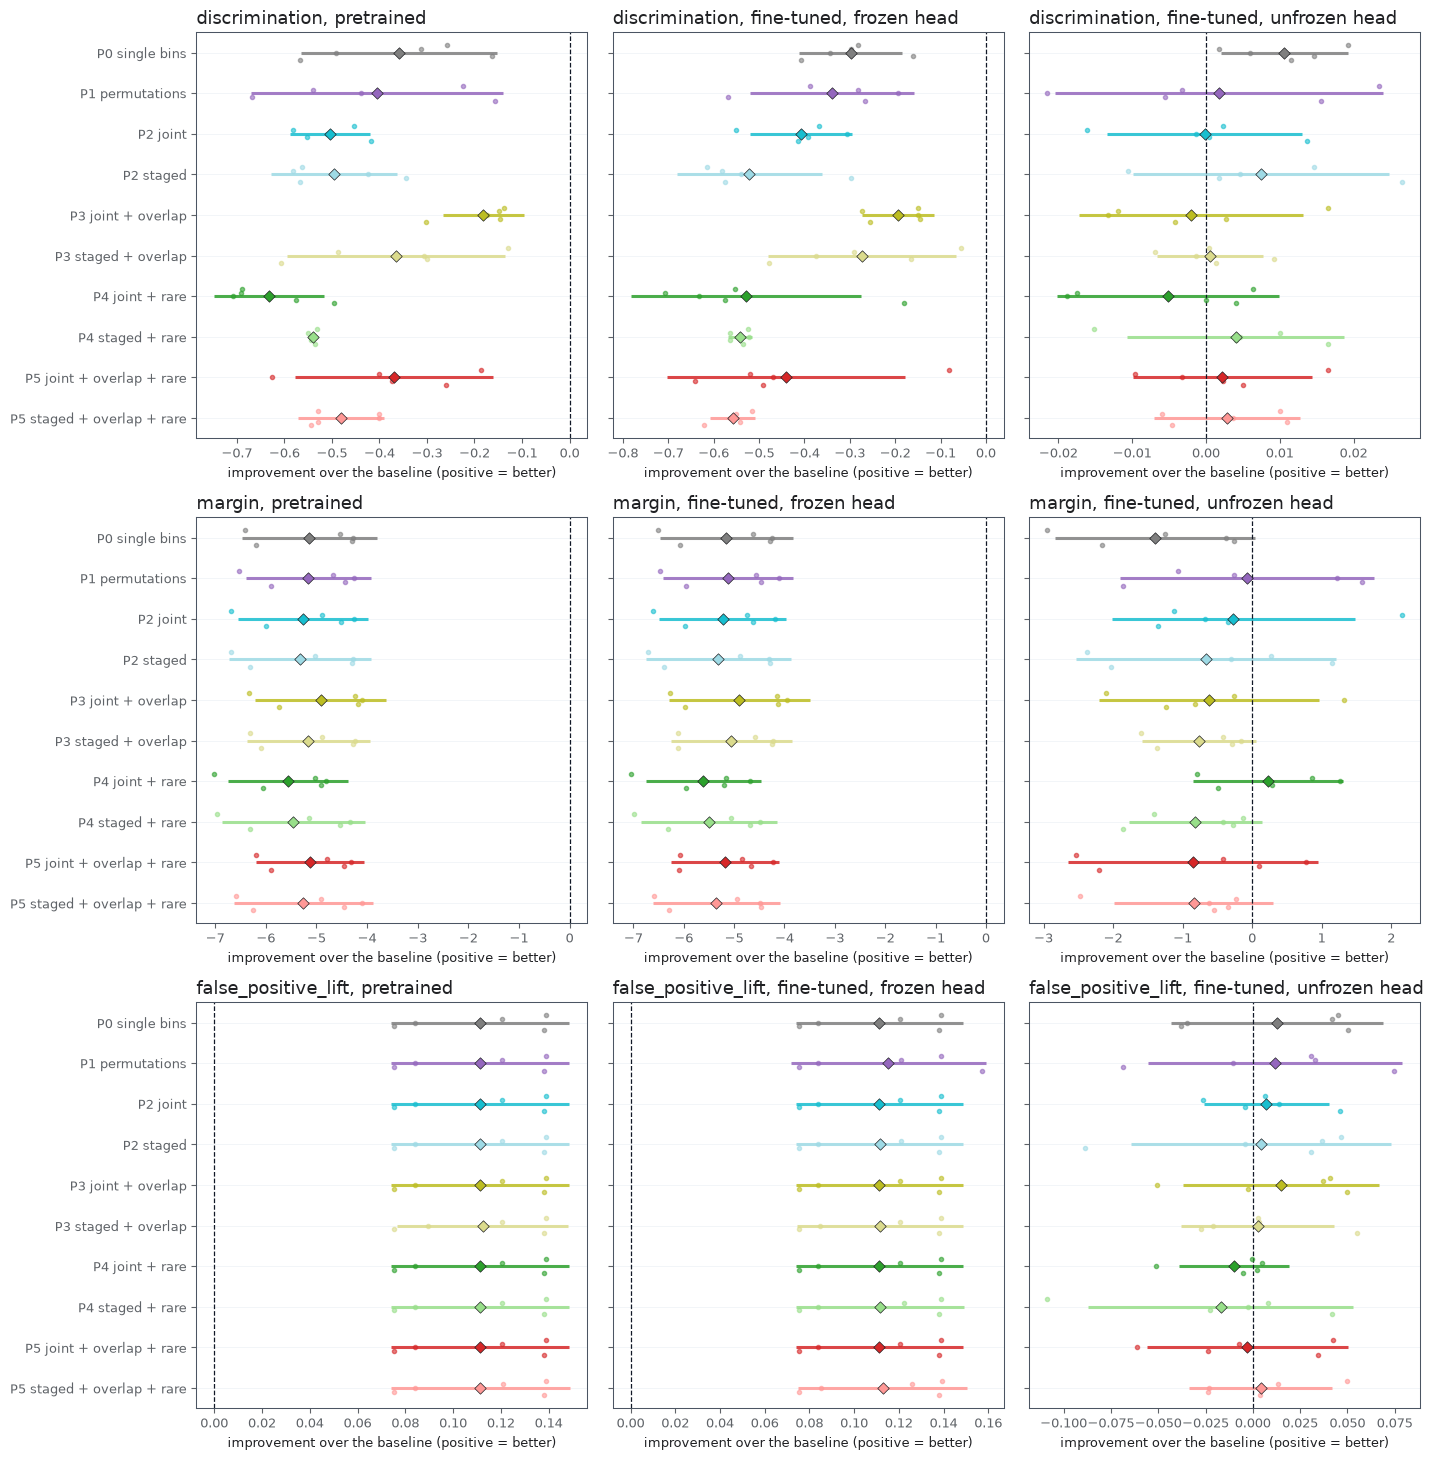

In [7]:
rows = baseline_summary[baseline_summary.evaluation == 'test_combined']
panels = [(f"{metric}, {STAGE_LABELS[stage]}", {'metric': metric, 'stage': stage})
          for metric in ['discrimination', 'margin', 'false_positive_lift'] for stage in STAGES]
paired = table('baseline_improvements')
figures.improvement_forest(rows, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS,
                           paired=paired[paired.evaluation == 'test_combined'], columns=3, theme=theme);
display(pair_summary[pair_summary.evaluation == 'test_combined'].groupby(['variant', 'stage'])[['discrimination', 'margin', 'false_positive_lift']]
        .mean().unstack('stage').reindex(ORDER).round(3))

### Remarks

- Baseline: discrimination 0.857, margin 5.15, false-positive lift 0.111. Unfrozen variants: discrimination 0.852-0.868, lift 0.0963-0.128.
- Pretrained and frozen stages: discrimination 0.225-0.676 (chance = 0.5; from well below to modestly above it) and a false-positive lift of 0. The zero lift is trivial: these heads never reach p = 0.5, so they have no false positives at all; their 'improvement' in lift over the baseline is an artefact of the threshold.
- Unfrozen stage against the baseline:
  - discrimination: better than the baseline for P0 single bins; worse for none.
  - false_positive_lift: better than the baseline for none; worse for none.
  - false_positive_rate_when_partner_present: better than the baseline for none; worse for none.
  - margin: better than the baseline for none; worse for none.

### Notes

## Overlap quota against the matched control

### Methodology

#### Theoretical

Variant with the overlap quota minus the same construction without it, paired by stage and repetition.

#### Implementation

`control_summary`.

#### Figure descriptions

Forest plot: rows = treated variants, panels = metric x stage.

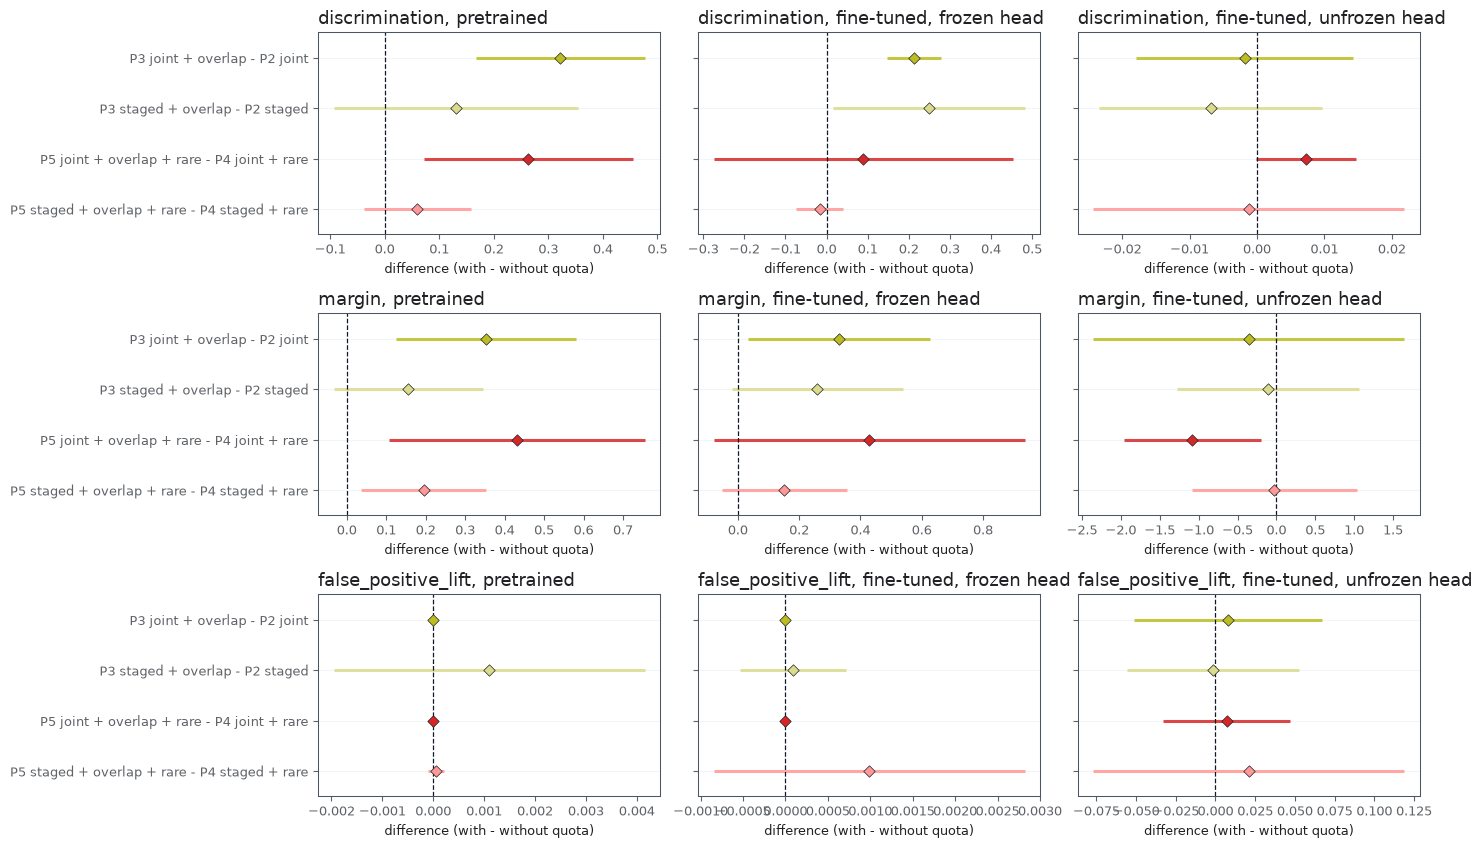

In [8]:
rows = table('control_summary')
rows = rows[rows.evaluation == 'test_combined']
figures.improvement_forest(rows, panels=panels, variants=TREATED, labels=PAIR_LABELS, colors=VARIANT_COLORS, columns=3,
                           xlabel='difference (with - without quota)', theme=theme);

### Remarks

- pretrained, P3 joint + overlap - P2 joint, discrimination: 0.322 [0.168, 0.477] (better with the quota).
- frozen head, P3 joint + overlap - P2 joint, discrimination: 0.212 [0.147, 0.278] (better with the quota).
- pretrained, P3 joint + overlap - P2 joint, margin: 0.353 [0.125, 0.581] (better with the quota).
- frozen head, P3 joint + overlap - P2 joint, margin: 0.331 [0.0337, 0.628] (better with the quota).
- frozen head, P3 staged + overlap - P2 staged, discrimination: 0.248 [0.0152, 0.482] (better with the quota).
- pretrained, P5 joint + overlap + rare - P4 joint + rare, discrimination: 0.263 [0.0717, 0.454] (better with the quota).
- pretrained, P5 joint + overlap + rare - P4 joint + rare, margin: 0.431 [0.106, 0.755] (better with the quota).
- unfrozen head, P5 joint + overlap + rare - P4 joint + rare, margin: -1.08 [-1.96, -0.2] (worse with the quota).
- pretrained, P5 staged + overlap + rare - P4 staged + rare, margin: 0.195 [0.0363, 0.353] (better with the quota).
- 39 of 48 matched cells are inconclusive.

### Notes

## Overlap classes against the other eligible classes

### Methodology

#### Theoretical

Macro AP over the overlap classes and over the other eligible classes, against the baseline and against the matched control.

#### Implementation

`set_summary` and `set_control_summary`.

#### Figure descriptions

No figure; interval strings per variant, class set and stage (test + extension).

In [9]:
sets = table('set_summary')
sets = sets[(sets.metric == 'average_precision') & (sets.evaluation == 'test_combined')]
display(sets.assign(result=interval(sets)).pivot_table(index='variant', columns=['ranking', 'stage'], values='result', aggfunc='first').reindex(VARIANTS))
controls = table('set_control_summary')
controls = controls[(controls.metric == 'average_precision') & (controls.evaluation == 'test_combined')]
display(controls.assign(result=interval(controls)).pivot_table(index='variant', columns=['ranking', 'stage'], values='result', aggfunc='first').reindex(TREATED))

ranking                             other_eligible                                                                                                  overlap                                   \
stage                                  frozen_head                       pretrained                          unfrozen_head                      frozen_head                       pretrained   
variant                                                                                                                                                                                        
P0_single           -0.53 [-0.587, -0.474] (+0/-5)  -0.676 [-0.747, -0.605] (+0/-5)       0.0146 [0.00695, 0.0223] (+5/-0)  -0.514 [-0.562, -0.466] (+0/-5)   -0.653 [-0.686, -0.62] (+0/-5)   
P1_permutation     -0.631 [-0.684, -0.578] (+0/-5)   -0.504 [-0.778, -0.23] (+0/-5)     0.00329 [-0.00376, 0.0103] (+4/-1)  -0.576 [-0.629, -0.523] (+0/-5)  -0.544 [-0.692, -0.397] (+0/-5)   
P2_joint_base      -0.531 [-0.615, -0.447] (+0/-5)  -0.718 [-0.732, -0.705] (+0/-5)  -0.000992 [-0.00784, 0.00585] (+3/-2)  -0.448 [-0.558, -0.339] (+0/-5)   -0.652 [-0.665, -0.64] (+0/-5)   
P2_staged_base     -0.554 [-0.611, -0.498] (+0/-5)  -0.708 [-0.744, -0.673] (+0/-5)   0.000276 [-0.00712, 0.00767] (+2/-3)  -0.473 [-0.545, -0.402] (+0/-5)  -0.644 [-0.714, -0.573] (+0/-5)   
P3_joint_overlap    -0.501 [-0.61, -0.393] (+0/-5)  -0.697 [-0.724, -0.671] (+0/-5)      0.00385 [-0.00525, 0.013] (+4/-1)  -0.388 [-0.474, -0.302] (+0/-5)  -0.644 [-0.665, -0.623] (+0/-5)   
P3_staged_overlap  -0.548 [-0.593, -0.503] (+0/-5)    -0.715 [-0.729, -0.7] (+0/-5)   0.00439 [-0.000194, 0.00897] (+5/-0)  -0.439 [-0.553, -0.325] (+0/-5)  -0.656 [-0.673, -0.639] (+0/-5)   
P4_joint_rare      -0.475 [-0.516, -0.433] (+0/-5)  -0.708 [-0.722, -0.693] (+0/-5)   0.000838 [-0.00414, 0.00581] (+2/-3)   -0.442 [-0.605, -0.28] (+0/-5)  -0.635 [-0.669, -0.602] (+0/-5)   
P4_staged_rare     -0.583 [-0.649, -0.517] (+0/-5)  -0.713 [-0.732, -0.694] (+0/-5)    0.00454 [0.000624, 0.00846] (+5/-0)  -0.535 [-0.596, -0.473] (+0/-5)   -0.648 [-0.706, -0.59] (+0/-5)   
P5_joint_all         -0.5 [-0.615, -0.384] (+0/-5)  -0.703 [-0.742, -0.665] (+0/-5)      0.00505 [-0.0042, 0.0143] (+3/-2)  -0.453 [-0.572, -0.335] (+0/-5)  -0.629 [-0.691, -0.566] (+0/-5)   
P5_staged_all       -0.598 [-0.646, -0.55] (+0/-5)   -0.72 [-0.732, -0.709] (+0/-5)     0.00529 [-0.00266, 0.0132] (+4/-1)   -0.56 [-0.666, -0.454] (+0/-5)   -0.656 [-0.681, -0.63] (+0/-5)   

ranking                                                 
stage                                    unfrozen_head  
variant                                                 
P0_single            0.0141 [-0.00704, 0.0351] (+5/-0)  
P1_permutation      0.000757 [-0.0433, 0.0449] (+3/-2)  
P2_joint_base        -0.00505 [-0.039, 0.0289] (+1/-4)  
P2_staged_base       0.00284 [-0.0389, 0.0445] (+3/-2)  
P3_joint_overlap      0.00228 [-0.036, 0.0406] (+3/-2)  
P3_staged_overlap     0.00485 [-0.0163, 0.026] (+1/-4)  
P4_joint_rare          -0.0161 [-0.0422, 0.01] (+1/-4)  
P4_staged_rare        0.0136 [-0.00578, 0.033] (+5/-0)  
P5_joint_all       -0.000507 [-0.0418, 0.0407] (+2/-3)  
P5_staged_all        0.0118 [-0.00925, 0.0329] (+3/-2)

ranking                               other_eligible                                                                                                  overlap                                      \
stage                                    frozen_head                          pretrained                       unfrozen_head                      frozen_head                          pretrained   
variant                                                                                                                                                                                             
P3_joint_overlap      0.0297 [-0.145, 0.205] (+4/-1)    0.0206 [-0.0115, 0.0528] (+4/-1)  0.00484 [-0.00261, 0.0123] (+4/-1)   0.0602 [-0.083, 0.203] (+3/-2)  0.00834 [-0.00879, 0.0255] (+4/-1)   
P3_staged_overlap   0.00662 [-0.0915, 0.105] (+2/-3)  -0.00623 [-0.0431, 0.0306] (+3/-2)  0.00411 [-0.00413, 0.0124] (+5/-0)  0.0342 [-0.0197, 0.088] (+3/-2)    -0.0127 [-0.069, 0.0436] (+4/-1)   
P5_joint_all        -0.0253 [-0.139, 0.0887] (+3/-2)   0.00431 [-0.0337, 0.0424] (+3/-2)   0.00421 [-0.0048, 0.0132] (+4/-1)  -0.0109 [-0.179, 0.157] (+1/-4)    0.00686 [-0.0613, 0.075] (+4/-1)   
P5_staged_all      -0.0152 [-0.0675, 0.0372] (+2/-3)  -0.00699 [-0.0307, 0.0167] (+2/-3)  0.000751 [-0.00952, 0.011] (+2/-3)   -0.0257 [-0.17, 0.119] (+2/-3)  -0.00767 [-0.0445, 0.0291] (+2/-3)   

ranking                                                  
stage                                     unfrozen_head  
variant                                                  
P3_joint_overlap       0.00733 [-0.0333, 0.048] (+3/-2)  
P3_staged_overlap     0.00201 [-0.0301, 0.0341] (+2/-3)  
P5_joint_all           0.0156 [-0.0167, 0.0479] (+3/-2)  
P5_staged_all      -0.00181 [-0.00789, 0.00428] (+1/-4)

### Remarks

- Macro AP per class set (overlap / other eligible) against the matched control, cells excluding zero: no cell excludes zero (36 of 36 cells inconclusive).

### Notes

## Ranking quality by number of annotated classes per pixel

### Methodology

#### Theoretical

Label-ranking average precision per pixel group (1, 2-3, 4-7, 8+ annotated classes). Pixels with many
co-occurring classes are where overlapping signals are most likely; an overlap-quota benefit should appear
there first.

#### Implementation

`cooccurrence_summary` (paired against the baseline).

#### Figure descriptions

Forest plot: rows = variants, panels = pixel group x evaluation at the unfrozen stage.

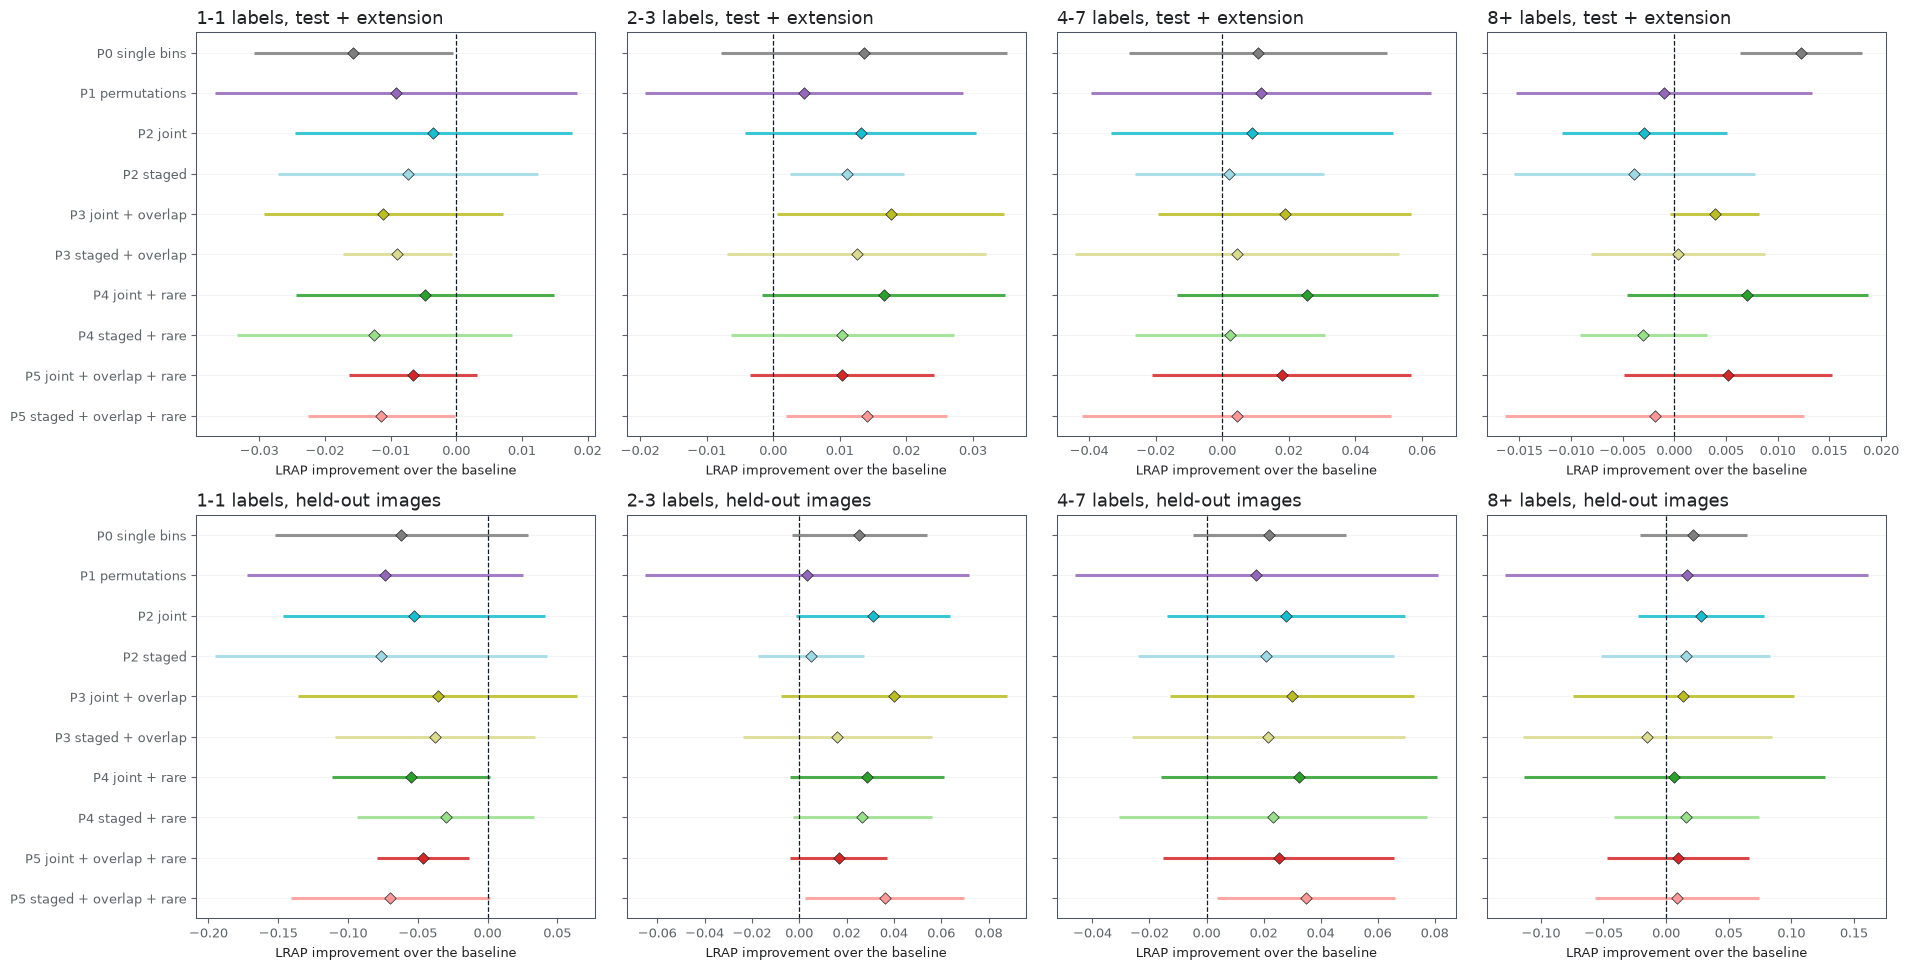

In [10]:
cooccurrence = table('cooccurrence_summary')
cooccurrence = cooccurrence[cooccurrence.stage == 'unfrozen_head']
panels = [(f"{group} labels, {EVALUATION_NAMES[evaluation]}", {'ranking': group, 'evaluation': evaluation})
          for evaluation in ['test_combined', 'heldout_image'] for group in ['1-1', '2-3', '4-7', '8+']]
figures.improvement_forest(cooccurrence, panels=panels, variants=VARIANTS, labels=VARIANT_LABELS, colors=VARIANT_COLORS, columns=4,
                           xlabel='LRAP improvement over the baseline', theme=theme);

### Remarks

- held-out, 1-1 labels: LRAP improvement -0.0763 to -0.0301; 0 better, 1 worse of 10 variants.
- held-out, 2-3 labels: LRAP improvement 0.00335 to 0.0401; 1 better, 0 worse of 10 variants.
- held-out, 4-7 labels: LRAP improvement 0.0175 to 0.035; 1 better, 0 worse of 10 variants.
- held-out, 8+ labels: LRAP improvement -0.015 to 0.0278; 0 better, 0 worse of 10 variants.
- test+ext, 1-1 labels: LRAP improvement -0.0157 to -0.00349; 0 better, 3 worse of 10 variants.
- test+ext, 2-3 labels: LRAP improvement 0.00461 to 0.0176; 3 better, 0 worse of 10 variants.
- test+ext, 4-7 labels: LRAP improvement 0.00207 to 0.0256; 0 better, 0 worse of 10 variants.
- test+ext, 8+ labels: LRAP improvement -0.00385 to 0.0122; 1 better, 0 worse of 10 variants.

### Notes

## Results / Summary

### LLM

- **Observed:** same 4 pairs, no held-out support. At the unfrozen stage discrimination equals the baseline's (0.85-0.87 against 0.86); the only unfrozen matched effect is a lower margin for P5 joint - P4 joint. Before full fine-tuning the quota raises discrimination on this axis (P3 joint, P3 staged at the frozen stage, P5 joint), i.e. the opposite sign of the 200-900 axis for the same class pairs.
- **Interpretation:** the pre-fine-tuning effects of the overlap quota are axis-dependent in sign and vanish after real fine-tuning; there is no consistent evidence that the quota helps to separate colliding classes.

**Absolute levels against the real-only baseline** (means over repetitions; 'better' compares means only, without a test; the intervals are in the improvement sections):

- test_combined | average_precision (by stage, variants pooled): baseline 0.7876; others 0.1264-0.7911; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7911), worst pretrained (0.1264).
- test_combined | average_precision (unfrozen head, per variant): baseline 0.7876; others 0.78-0.8019; 8 of 10 better than the baseline; best P0 single bins (0.8019), worst P4 joint + rare (0.78).
  best single cell: P0 single bins, fine-tuned, unfrozen head (0.8019 vs baseline 0.7876).
- test_combined | recall (by stage, variants pooled): baseline 0.7614; others 0.001505-0.7672; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.7672), worst fine-tuned, frozen head (0.001505).
- test_combined | recall (unfrozen head, per variant): baseline 0.7614; others 0.7439-0.7875; 6 of 10 better than the baseline; best P4 staged + rare (0.7875), worst P1 permutations (0.7439).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.7875 vs baseline 0.7614).
- heldout_image | average_precision (by stage, variants pooled): baseline 0.08724; others 0.05764-0.09105; 1 of 3 better than the baseline; best fine-tuned, unfrozen head (0.09105), worst fine-tuned, frozen head (0.05764).
- heldout_image | average_precision (unfrozen head, per variant): baseline 0.08724; others 0.08506-0.09499; 8 of 10 better than the baseline; best P4 staged + rare (0.09499), worst P1 permutations (0.08506).
  best single cell: P4 staged + rare, fine-tuned, unfrozen head (0.09499 vs baseline 0.08724).
- heldout_image | recall (by stage, variants pooled): baseline 0.007415; others 0-0.007354; 0 of 3 better than the baseline; best fine-tuned, unfrozen head (0.007354), worst fine-tuned, frozen head (0).
- heldout_image | recall (unfrozen head, per variant): baseline 0.007415; others 0.003851-0.01237; 5 of 10 better than the baseline; best P5 joint + overlap + rare (0.01237), worst P3 joint + overlap (0.003851).
  best single cell: P5 joint + overlap + rare, fine-tuned, unfrozen head (0.01237 vs baseline 0.007415).

### Person